## Representaciones vectoriales

**Objetivo**

Este análisis documenta y pone en práctica  conceptos de repreentaciones vectoriales, con el fin de explorar y comparar dos enfoques de representación semántica: embeddings estáticos y embeddings contextuales. El notebook se organiza en dos bloques de trabajo, cada uno con un flujo de actividades diseñado para observar el comportamiento de los embeddings, su capacidad para capturar similitud y relaciones semánticas, y su interpretación mediante visualizaciones.

**Embeddings estáticos con Word2Vec**.

En esta sección se utiliza un corpus de noticias para entrenar un modelo Word2Vec (CBOW) y analizar las representaciones vectoriales resultantes. El objetivo es evaluar qué tan bien capturan relaciones semánticas entre palabras y cómo se comportan bajo operaciones en el espacio vectorial:

1. Preprocesamiento y tokenización (*)
2. Entrenamiento de Word2Vec con CBOW (*)
3. Evaluación y comparación de embeddings (*)
4. Operaciones vectoriales (*)
5. Visualización 2D de embeddings de palabras

**Embeddings contextuales con BETO**.

En esta sección se trabaja con documentos en español y se emplea BETO como modelo preentrenado para extraer embeddings contextuales. El propósito es analizar cómo varía la representación dependiendo del contexto y medir la similitud entre documentos usando sus embeddings:

1. Dataset de documentos pequeños
2. Carga del modelo y tokenizador BETO (*)
3. Función para extraer embeddings (*)
4. Comparación de documentos (*)
5. Visualización 2D de embeddings
6. Ejecución principal del código



# Embeddings estáticos con Word2Vec

In [1]:
#pip install gensim nltk sentence-transformers transformers torch scikit-learn numpy pandas matplotlib seaborn

In [1]:
# Librerias

import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\altom\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\altom\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\altom\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# 1. Cargar Dataset 20 Newsgroups (aqui NO es necesario código)

print("=== Cargando Dataset 20 Newsgroups ===")
ds = fetch_20newsgroups(subset="all", remove=("headers","footers","quotes"))
X_text, y = ds.data, ds.target
target_names = ds.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total documentos: {len(X_text)}")
print(f"Train: {len(X_train)} documentos")
print(f"Test: {len(X_test)} documentos")
print(f"Categorías: {target_names}")


=== Cargando Dataset 20 Newsgroups ===
Total documentos: 18846
Train: 15076 documentos
Test: 3770 documentos
Categorías: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [3]:
# 2. Preprocesamiento y Tokenización (aqui SI es necesario código)

print("\n=== Preprocesamiento y Tokenización ===")
stop_words = set(stopwords.words('english'))
punctuation = set(string.punctuation)


=== Preprocesamiento y Tokenización ===


In [4]:


def preprocess_text(text):
    """
    Limpia y tokeniza el texto

    Args:
        text: documento del dataset

    Returns:
        tokens: lista de tokens del documento
    """

    if text is None:
        return []

    # ********************************
    # OBJETIVO: Convertir a minúsculas y tokenizar
    # TO-DO:
    #   1. pasar a minusculas los textos de entrada 'text'
    #   2. tokenizar los textos de entrada 'text'
    # TIPS:
    #   1. Para convertir el texto a minusculas se puede utilizar el método lower() sobre 'text'
    #   2. Para tokenizar se puede utilizar la funcion word_tokenize() que ya viene cargada desde la libreria de nltk, la cual recibe el 'text'
    #
    # complentar y descomentar las siguientes lineas (text, tokens):
    # ********************************

    text = text.lower()
    tokens = word_tokenize(text)

    return tokens

# Preprocesar solo un subset
print("Preprocesando documentos...")
X_train_processed = [preprocess_text(doc) for doc in X_train[:1000]]  # Usar solo 1000 docs para velocidad
X_train_processed = [doc for doc in X_train_processed if len(doc) > 5]  # Filtrar documentos muy cortos

print(f"Documentos procesados: {len(X_train_processed)}")
print(f"Ejemplo de tokens: {X_train_processed[0][:10]}")  # Mostrar primeros 10 tokens del primer doc


'''
SALIDA ESPERADA:
Preprocesando documentos...
Documentos procesados: 968
Ejemplo de tokens: ['no', 'doubt', 'this', 'is', 'an', 'old', 'question', ',', 'but', 'i']
'''

Preprocesando documentos...
Documentos procesados: 968
Ejemplo de tokens: ['no', 'doubt', 'this', 'is', 'an', 'old', 'question', ',', 'but', 'i']


"\nSALIDA ESPERADA:\nPreprocesando documentos...\nDocumentos procesados: 968\nEjemplo de tokens: ['no', 'doubt', 'this', 'is', 'an', 'old', 'question', ',', 'but', 'i']\n"

In [5]:
y_train

array([ 5, 16,  1, ..., 14, 11, 16])

In [6]:
# 3. Entrenar Modelo Word2Vec con CBOW (aqui SI es necesario código)

# ********************************
    # OBJETIVO: Entrenar Modelo Word2Vec con CBOW
    # TO-DO:
    #   1. entrear modelo model_w2v, pasar textos y definir parámetros
    #   definir los parametros del modelo: sentences (X_train_processed), vector_size, window, min_count, sg (0), epochs
    # TIPS:
    #   1. utilizar Word2Vec() que ya viene definido en la librerias de gensim
    #   referencia: https://radimrehurek.com/gensim/models/word2vec.html
    # complentar y descomentar las siguientes lineas (model_w2v):
# ********************************

model_w2v =  Word2Vec(sentences=X_train_processed, vector_size=30, window=5, min_count=3, sg=0, epochs=10)


print(f"Vocabulario: {len(model_w2v.wv.key_to_index)} palabras")
print(f"Ejemplo de palabras en vocabulario: {list(model_w2v.wv.key_to_index.keys())[:20]}")


#SALIDA ESPERADA:
#Vocabulario: 4621 palabras
#Ejemplo de palabras en vocabulario: ['>', "'ax", ',', '.',...]


Vocabulario: 7727 palabras
Ejemplo de palabras en vocabulario: ['>', "'ax", ',', '.', 'the', '--', '(', ')', 'to', 'of', 'and', 'a', '*', '@', ':', 'i', "''", '``', 'in', 'is']


In [7]:
# 4. Evaluar y Comparar Embeddings (aqui SI es necesario código)

print("\n=== Comparación de Embeddings ===")
# Palabras para comparar:
# tecnologia: 'computer', 'software', 'hardware', 'windows', 'linux', 'mac', 'email', 'internet'
# deporte: 'game', 'team', 'player', 'season', 'hockey', 'baseball', 'football', 'basketball'
# ciencia: 'science', 'research', 'data', 'study', 'university', 'medical', 'health', 'disease'
palabra_1 = 'computer'
palabra_2 = 'game'

def comparar_palabras(model, palabra_1, palabra_2):
    """Compara similitud de palabras"""

    # ********************************
    # OBJETIVO: Evaluar y Comparar Embeddings
    # TO-DO:
    #   1. extraer embeddings de las palabras: palabra_1, palabra_2
    #   2. calcular las similitudes entre embeddings de palabras: palabra_1, palabra_2
    #   puedes seleccionar cualquier par de palabras definidas arriba y obtener su simlitud
    # TIPS:
    #   1. para extraer el embedding del modelo entrenado: model.wv[emb] (donde emb es la palabra)
    #   2. utilizar cosine_similarity() que ya viene cargada en las librerias
    #   esta funcion revice los dos embeddings a comparar en similitud: cosine_similarity(emb1, emb2)
    # complentar y descomentar las siguientes lineas (vector_palabra_1, vector_palabra_2, similitud):
    # ********************************

    #1. extraer embeddings de las palabras (vectorizar text)
    vector_palabra_1 = model.wv[palabra_1[0]].reshape(1, -1)
    vector_palabra_2 = model.wv[palabra_2[0]].reshape(1, -1)
    #2. calcular las similitudes entre embeddings de palabras
    similitud = cosine_similarity(vector_palabra_1, vector_palabra_2)


    print(f"Similitud entre {palabra_1[0]} y {palabra_2[0]}:", similitud[0][0])


# Comparar diferentes grupos de palabras
comparar_palabras(model_w2v, [palabra_1], [palabra_2])


#SALIDA ESPERADA:
#Similitud entre computer y game: 0.47474545




=== Comparación de Embeddings ===
Similitud entre computer y game: 0.5525127


In [8]:
# 5. Operaciones Vectoriales (aqui SI es necesario código)

print("\n=== Operaciones Vectoriales ===")

operacion1 = ['computer', 'mac', 'windows']
desc_op1 = "computer - mac + windows"

operacion2 = ['game', 'hockey', 'baseball']
desc_op2 = "game - hockey + baseball"

# ********************************
    # OBJETIVO: Operaciones Vectoriales
    # TO-DO:
    #   1. obtener resultado_op_1 como reusltados de la operacion: computer - mac + windows
    #   2. obtener resultado_op_2 como reusltados de la operacion: game - hockey + baseball
    # TIPS:
    #   utilizar el metodo: model_w2v.wv.most_similar()
    #   este metodo recive los parametros:
    #     positive=[], que indican los valores positivos: por ejemplo 'computer' y 'windows'
    #     negative=[], que indican los valores negativos: por ejmeplo 'mac'
	  #     topn, indica el numero de resultdos a retornar: por ejemplo topn=3
    # complentar y descomentar las siguientes lineas (resultado_op_1, resultado_op_2):
    # ********************************

# obtener resultados de las Operaciones Vectoriales
# 1. computer - mac + windows
#resultado_op_1 = ...
# 2. game - hockey + baseball
#resultado_op_2 = ...

resultado_op_1 = model_w2v.wv.most_similar(positive=['computer', 'windows'], negative=['mac'], topn=3)
# 2. game - hockey + baseball
resultado_op_2 = model_w2v.wv.most_similar(positive=['game', 'baseball'], negative=['hockey'], topn=3)

print(desc_op1)
for palabra, similitud in resultado_op_1:
  print(f"  {palabra}: {similitud:.4f}")
print(desc_op2)
for palabra, similitud in resultado_op_2:
  print(f"  {palabra}: {similitud:.4f}")

#SALIDA ESPERADA:
#computer - mac + windows
#  next: 0.8694
#  man: 0.8684
#  year: 0.8636
#game - hockey + baseball
#  team: 0.8792
#  contract: 0.8551
#  issue: 0.8545



=== Operaciones Vectoriales ===
computer - mac + windows
  power: 0.8257
  access: 0.8241
  exploring: 0.8225
game - hockey + baseball
  first: 0.8801
  day: 0.8768
  team: 0.8511


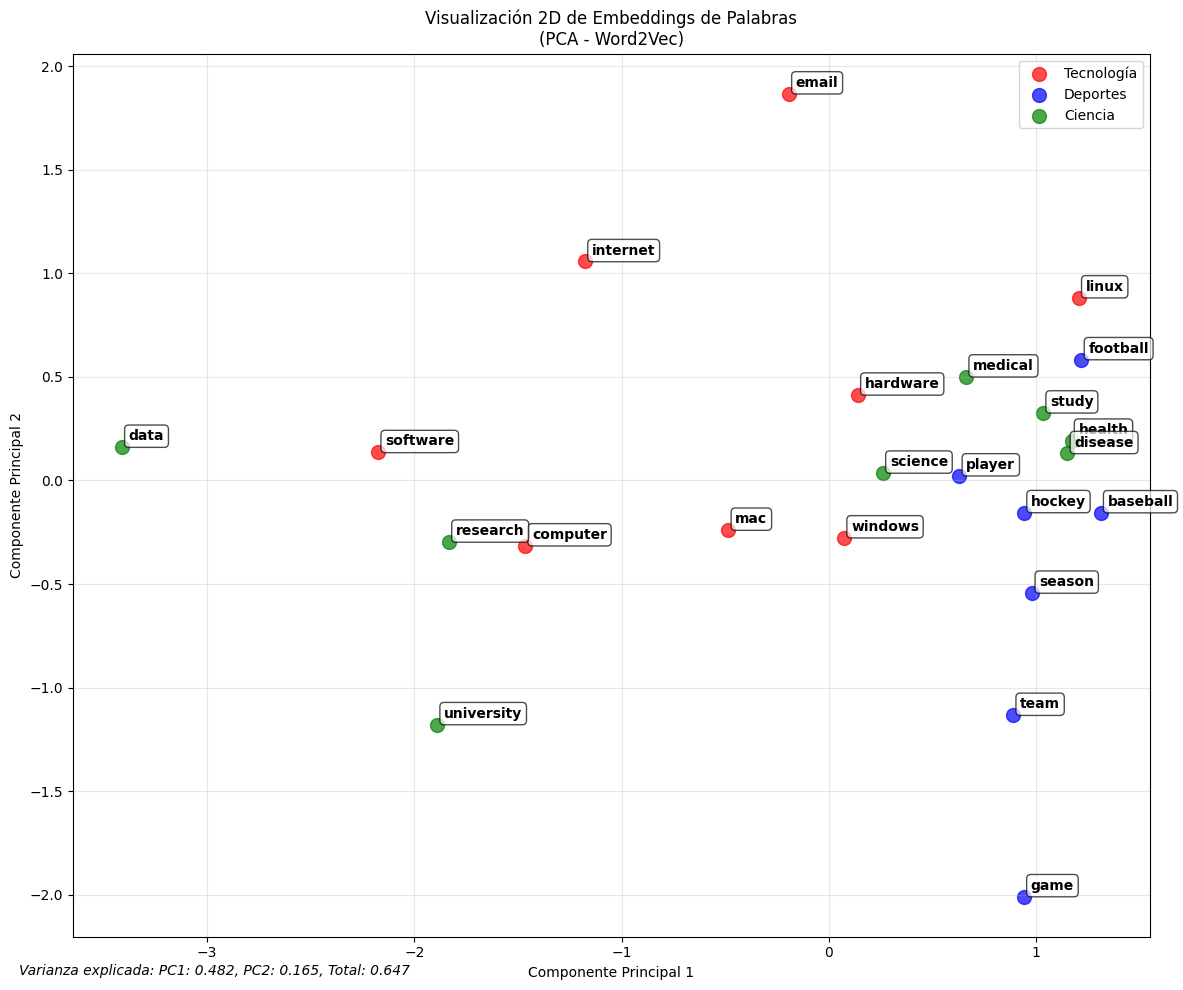

Palabras visualizadas: 23


In [9]:
#6. Visualización 2D de Embeddings de Palabras (aqui NO es necesario código)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

def visualizar_palabras_2d(model, palabras_tecnologia, palabras_deporte, palabras_ciencia):
    """
    Visualiza embeddings de palabras en 2D usando PCA
    """
    # Combinar todas las palabras y filtrar las que están en el vocabulario
    todas_palabras = palabras_tecnologia + palabras_deporte + palabras_ciencia
    palabras_validas = [p for p in todas_palabras if p in model.wv]

    if len(palabras_validas) < 3:
        print("No hay suficientes palabras válidas para visualizar")
        return

    # Obtener embeddings
    embeddings = [model.wv[palabra] for palabra in palabras_validas]

    # Aplicar PCA para reducir a 2D
    pca = PCA(n_components=2, random_state=42)
    embeddings_2d = pca.fit_transform(embeddings)

    # Crear gráfico
    plt.figure(figsize=(12, 10))

    # Separar palabras por categoría para colorear
    tech_indices = [i for i, p in enumerate(palabras_validas) if p in palabras_tecnologia]
    sport_indices = [i for i, p in enumerate(palabras_validas) if p in palabras_deporte]
    science_indices = [i for i, p in enumerate(palabras_validas) if p in palabras_ciencia]

    # Graficar puntos
    plt.scatter(embeddings_2d[tech_indices, 0], embeddings_2d[tech_indices, 1],
                c='red', s=100, alpha=0.7, label='Tecnología')
    plt.scatter(embeddings_2d[sport_indices, 0], embeddings_2d[sport_indices, 1],
                c='blue', s=100, alpha=0.7, label='Deportes')
    plt.scatter(embeddings_2d[science_indices, 0], embeddings_2d[science_indices, 1],
                c='green', s=100, alpha=0.7, label='Ciencia')

    # Añadir etiquetas de palabras
    for i, palabra in enumerate(palabras_validas):
        plt.annotate(palabra, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.title('Visualización 2D de Embeddings de Palabras\n(PCA - Word2Vec)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Información de varianza
    var_explicada = pca.explained_variance_ratio_
    plt.figtext(0.02, 0.02, f'Varianza explicada: PC1: {var_explicada[0]:.3f}, PC2: {var_explicada[1]:.3f}, Total: {sum(var_explicada):.3f}',
                fontsize=10, style='italic')

    plt.tight_layout()
    plt.show()

    print(f"Palabras visualizadas: {len(palabras_validas)}")

palabras_tecnologia = ['computer', 'software', 'hardware', 'windows', 'linux', 'mac', 'email', 'internet']
palabras_deporte = ['game', 'team', 'player', 'season', 'hockey', 'baseball', 'football', 'basketball']
palabras_ciencia = ['science', 'research', 'data', 'study', 'university', 'medical', 'health', 'disease']
# Llamar a la función de visualización
visualizar_palabras_2d(model_w2v, palabras_tecnologia, palabras_deporte, palabras_ciencia)

# Embeddings contextuales con BETO

In [10]:
# Librerías
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


c:\Users\altom\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# 1. Dataset de documentos pequeños (aqui NO es necesario código)

documentos = [
    "Los gatos son animales domésticos muy populares. Son conocidos por su independencia y elegancia. Muchas personas tienen gatos como mascotas en sus hogares.",
    "Los felinos domésticos, comúnmente llamados gatos, son mascotas queridas en muchas familias. Su comportamiento independiente los hace animales de compañía ideales para algunos.",
    "Los perros son considerados el mejor amigo del hombre. Son animales leales y protectores que disfrutan de la compañía humana y necesitan ejercicio regular.",
    "Los caninos son animales sociales que han sido domesticados por miles de años. Su lealtad y capacidad de protección los hacen excelentes compañeros para las personas.",
    "La inteligencia artificial está transformando la industria tecnológica. Los avances en machine learning permiten resolver problemas complejos de manera eficiente.",
    "El procesamiento de lenguaje natural permite a las computadoras entender e interpretar el lenguaje humano. Técnicas como transformers revolucionaron la traducción automática y el análisis de texto."
]

categorias = ["Gatos", "Gatos", "Perros", "Perros", "IA", "IA"]


In [12]:
# 2. Cargar modelo y tokenizador BETO (aqui SI es necesario código)

def cargar_modelo_bert(model_name='dccuchile/bert-base-spanish-wwm-uncased'):
    """
    Carga modelo BETO y tokenizador

    Args:
        model_name: Nombre del modelo pre-entrenado

    Returns:
        tokenizer: Tokenizador de BETO
        model: Modelo BETO
    """

    # ********************************
    # OBJETIVO: cargar y retornar: tokenizer y model
    # TO-DO:
    #   1. Cargar BETO tokenizer
    #   2. Cargar BETO model
    # TIPS:
    #   1. Cargar tokenizer: utilizar la libreria AutoTokenizer y el método from_pretrained(model_name)
    #   2. Cargar model: utilizar la libreria AutoModel y el método from_pretrained(model_name)
    #
    # complentar y descomentar las siguientes lineas (tokenizer, model):
    # ********************************

    # 1. cargar tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # 2. cargar model
    model = AutoModel.from_pretrained(model_name)

    return tokenizer, model



# NO HAY SALIDA ESPERADA: SOLO EN LA EJECUCION PRINCIAL (ULTIMA CELDA)

In [13]:
# 3. Función para extraer embeddings (aqui SI es necesario código)

def extraer_embeddings_bert(tokenizer, model, textos, estrategia='mean'):
    """
    Extrae embeddings de documentos usando BERT

    Args:
        tokenizer: Tokenizador de BERT
        model: Modelo BERT
        textos: Lista de textos/documentos
        estrategia: 'cls' para usar token [CLS] o 'mean' para mean pooling

    Returns:
        embeddings: Array con los embeddings extraídos
    """

    # ********************************
    # OBJETIVO: Tokenizar texto,  Obtener outputs del modelo y extraer CLS Token y Mean Pooling
    # TO-DO:
    #   1. Para tokenizar texto: utilizar la funcion tokenizer() (que ya viene cargada desde las librerías), la idea es pasar el texto y parametros necesario
    #   2. Para obtener outputs del modelo de las capas: pasar los **inputs al model(...) y utilizar el método last_hidden_state de la variable model
    #   3. Para la Estrategia CLS: utilizar el last_hidden_state del paso 2
    #   4. Para la Estrategia Mean Pooling: utilizar el last_hidden_state del paso 2 y hacer agregaicon de embeddings con torch.mean(...)
    # TIPS:
    #   1. como entrada en esta función tenemos 'textos' para poder tokenizar el texto
    #   2. como entrada en esta función tenemos 'model' el cual recive como entrada los **inptus y para obtener los embeddings podemos utilizar el método last_hidden_state
    #   3. para obtener el token CLS, debemos acceder al array 'last_hidden_state' de la siguiente manera: last_hidden_state[:, 0, :]
    #   4. para hacer el Mean Pooling de los embeddings podemos utilizar la funcion torch.mean(...) y pasar como entrada los last_hidden_state
    #
    # complentar y descomentar las siguientes lineas (inputs, outputs, last_hidden_state, embedding):
    # ********************************

    embeddings = []
    for texto in textos:
        # 1. Tokenizar texto
        inputs = tokenizer(texto, return_tensors='pt', padding=True, truncation=True, max_length=512)

        # 2. Obtener outputs del modelo
        with torch.no_grad():
            outputs = model(**inputs)
            last_hidden_state = outputs.last_hidden_state

        # 3. Estrategia CLS
        if estrategia == 'cls':
            embedding = last_hidden_state[:, 0, :].numpy().flatten()

        # 4. Estrategia Mean Pooling
        elif estrategia == 'mean':
            embedding = torch.mean(last_hidden_state, dim=1).numpy().flatten()
        
        else:
            raise ValueError("Estrategia no válida. Elija 'cls' o 'mean'.")

        embeddings.append(embedding)

    return np.array(embeddings)



# NO HAY SALIDA ESPERADA: SOLO EN LA EJECUCION PRINCIAL (ULTIMA CELDA)


In [14]:

# 4. Comparar documentos (aqui SI es necesario código)

def comparar_documentos_bert(embeddings_cls, embeddings_mean, documentos):
    """
    Compara documentos usando ambas estrategias de embedding
    """
    print("=== BERT para Documentos ===")


    # ********************************
    # OBJETIVO: Calcular similitudes coseno
    # TO-DO: complear estas dos líneas de codigo para hacer la comparacion de embeddings
    # TIPS: usar la funcion 'cosine_similarity()' (que ya viene cargada desde las librerías) y usar las variables/listas embeddings_cls y embeddings_mean
    #
    # complentar y descomentar las siguientes lineas (similitudes_cls y similitudes_mean):
    # ********************************

    #similitudes_cls = ...
    #similitudes_mean = ...


    similitudes_cls = cosine_similarity(embeddings_cls)
    similitudes_mean = cosine_similarity(embeddings_mean)


    # Mostrar comparaciones
    pares_comparar = [(0, 1), (2, 3), (4, 5), (0, 2), (0, 4)]
    print("\n=== Comparación de Estrategias ===")
    print("Documento 1: Sobre gatos")
    print("Documento 2: Sobre gatos (similar)")
    print("Documento 3: Sobre perros")
    print("Documento 4: Sobre perros (similar)")
    print("Documento 5: Sobre IA")
    print("Documento 6: Sobre IA (similar)\n")

    for i, j in pares_comparar:
        sim_cls = similitudes_cls[i][j]
        sim_mean = similitudes_mean[i][j]
        print(f"Documentos {i+1} vs {j+1}:")
        print(f"   CLS Token - Similitud: {sim_cls:.4f}")
        print(f"   Mean Pooling - Similitud: {sim_mean:.4f}")
        print(f"   Diferencia: {abs(sim_cls - sim_mean):.4f}\n")



    # Visualizar embeddings en 2D
    visualizar_embeddings_2d(embeddings_cls, categorias, "Embeddings - CLS Token")
    visualizar_embeddings_2d(embeddings_mean, categorias, "Embeddings - Mean Pooling")




# NO HAY SALIDA ESPERADA: SOLO EN LA EJECUCION PRINCIAL (ULTIMA CELDA)


In [15]:
# 5. Visualización 2D de embeddings (aqui NO es necesario código)

def visualizar_embeddings_2d(embeddings, categorias, titulo):
    """
    Visualiza embeddings en 2D usando PCA
    """
    # Aplicar PCA
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)

    # Crear gráfico
    plt.figure(figsize=(10, 8))

    # Colores para cada categoría
    colores = {'Gatos': 'red', 'Perros': 'blue', 'IA': 'green'}

    for i, (x, y) in enumerate(embeddings_2d):
        categoria = categorias[i]
        plt.scatter(x, y, c=colores[categoria], s=100, alpha=0.7, label=categoria if i == categorias.index(categoria) else "")
        plt.annotate(f'Doc {i+1}', (x, y), xytext=(5, 5), textcoords='offset points', fontweight='bold')

    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.title(f'{titulo}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


  # NO HAY SALIDA ESPERADA: SOLO EN LA EJECUCION PRINCIAL (ULTIMA CELDA)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
c:\Users\altom\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\altom\.cache\huggingface\hub\models--dccuchile--bert-base-spanish-wwm-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to act

=== BERT para Documentos ===

=== Comparación de Estrategias ===
Documento 1: Sobre gatos
Documento 2: Sobre gatos (similar)
Documento 3: Sobre perros
Documento 4: Sobre perros (similar)
Documento 5: Sobre IA
Documento 6: Sobre IA (similar)

Documentos 1 vs 2:
   CLS Token - Similitud: 0.7936
   Mean Pooling - Similitud: 0.8749
   Diferencia: 0.0814

Documentos 3 vs 4:
   CLS Token - Similitud: 0.8557
   Mean Pooling - Similitud: 0.8595
   Diferencia: 0.0038

Documentos 5 vs 6:
   CLS Token - Similitud: 0.7028
   Mean Pooling - Similitud: 0.7925
   Diferencia: 0.0897

Documentos 1 vs 3:
   CLS Token - Similitud: 0.7568
   Mean Pooling - Similitud: 0.7995
   Diferencia: 0.0427

Documentos 1 vs 5:
   CLS Token - Similitud: 0.5648
   Mean Pooling - Similitud: 0.5966
   Diferencia: 0.0319



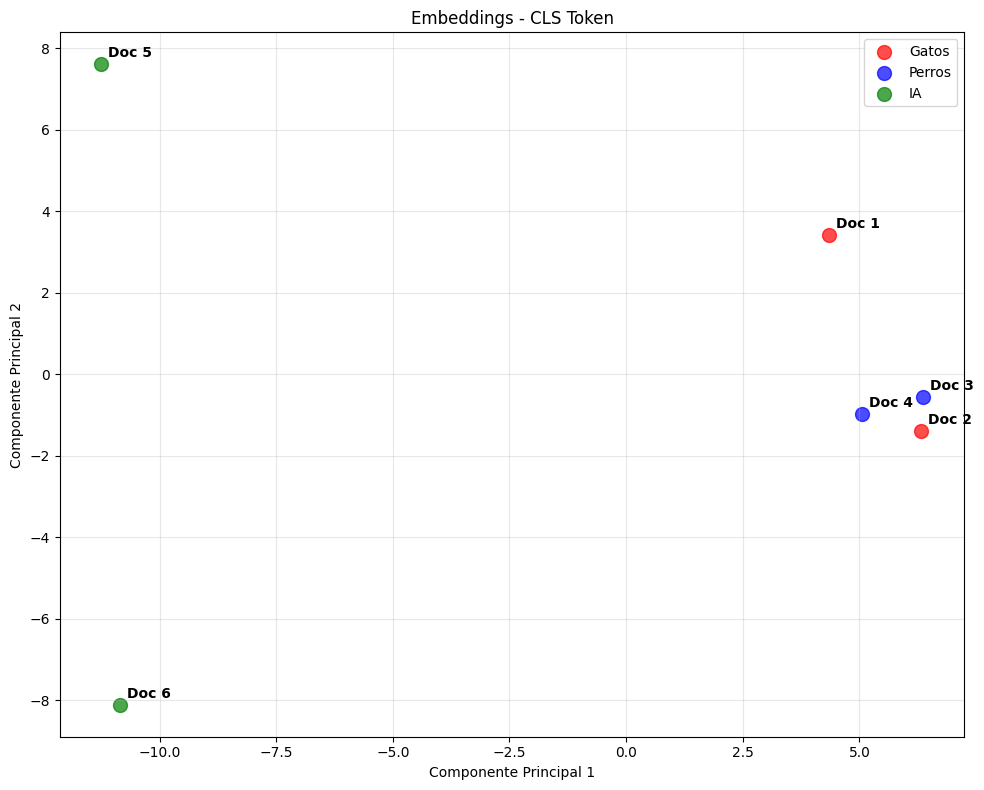

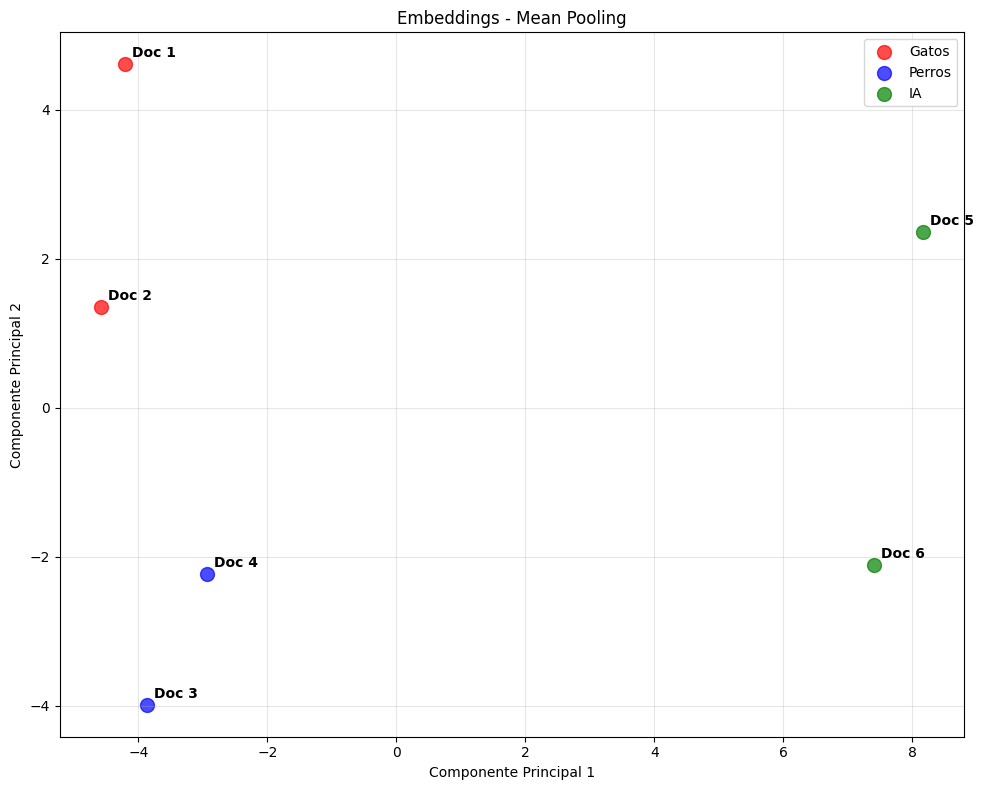

'\n=== Comparación de Estrategias ===\nDocumento 1: Sobre gatos\nDocumento 2: Sobre gatos (similar)\nDocumento 3: Sobre perros\nDocumento 4: Sobre perros (similar)\nDocumento 5: Sobre inteligencia artificial\n\nDocumento 6: Sobre PLN\nDocumentos 1 vs 2:\n  CLS Token - Similitud: 0.7936\n  Mean Pooling - Similitud: 0.8749\n  Diferencia: 0.0814\n  ...\n\nGRAFICO en 2D para visualizar los embeddings de documentos utilizando [CLS] token y Mean Pooling\nDado que con el método de Mean Pooling se obtiene embeddings mas representativos que el token [CLS]\nesperariamos ver en el gráfico 2D que para los primeros los documentos estén mejor agrupados por su tipo de documento\n'

In [16]:
# 6. Ejecutación principal del codigo (aqui NO es necesario código)

tokenizer, model_bert = cargar_modelo_bert()
embeddings_cls = extraer_embeddings_bert(tokenizer, model_bert, documentos, 'cls')
embeddings_mean = extraer_embeddings_bert(tokenizer, model_bert, documentos, 'mean')

comparar_documentos_bert(embeddings_cls, embeddings_mean, documentos)

print("\n")
# SALIDA ESPERADA:
'''
=== Comparación de Estrategias ===
Documento 1: Sobre gatos
Documento 2: Sobre gatos (similar)
Documento 3: Sobre perros
Documento 4: Sobre perros (similar)
Documento 5: Sobre inteligencia artificial

Documento 6: Sobre PLN
Documentos 1 vs 2:
  CLS Token - Similitud: 0.7936
  Mean Pooling - Similitud: 0.8749
  Diferencia: 0.0814
  ...

GRAFICO en 2D para visualizar los embeddings de documentos utilizando [CLS] token y Mean Pooling
Dado que con el método de Mean Pooling se obtiene embeddings mas representativos que el token [CLS]
esperariamos ver en el gráfico 2D que para los primeros los documentos estén mejor agrupados por su tipo de documento
'''

In [20]:
pip uninstall -y tensorflow

Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Note: you may need to restart the kernel to use updated packages.
